# Finnish BERT — Embedding Quality Evaluation

## What this notebook does

This notebook evaluates the sentence embedding quality of a Finnish BERT model trained from scratch using Masked Language Modelling (MLM). We compare a **trained checkpoint** (45 000 optimiser steps) against a **randomly initialised baseline** of the same architecture to isolate the effect of pre-training.

## Pipeline recap

The model was built end-to-end in seven stages:

| Script | What it does |
|--------|--------------|
| `01_data_download.py` | Downloads all Finnish plain-text books from Project Gutenberg (~3,600 books) |
| `02_clean.py` | Strips Gutenberg boilerplate, repairs hard-wrapped lines, splits into paragraphs, deduplicates |
| `03_tokenizer.py` | Trains a 50 000-token BPE vocabulary from scratch on a 200 K paragraph sample |
| `04_dataset.py` | Builds a PyTorch dataset with BERT-style Whole Word Masking (WWM, dynamic per epoch) |
| `05_model.py` | Implements BertForMLM: 6-layer / 256-hidden / 4-head Transformer encoder + MLM head |
| `06_train.py` | Pre-trains on 2 M paragraphs with AdamW, linear warmup + cosine decay, fp16 |
| `07_evaluate.py` | Provides metric functions and test sentences (imported here) |

## Evaluation metrics

We use four complementary metrics from the sentence embedding literature:

| Metric | Paper | What it measures | Good direction |
|--------|-------|-----------------|----------------|
| **Anisotropy** | Ethayarajh 2019 | How concentrated embeddings are in a narrow cone | ↓ lower is better |
| **Uniformity** | Wang & Isola 2020 | How evenly embeddings spread over the unit hypersphere | ↓ more negative is better |
| **Alignment** | Wang & Isola 2020 | How close positive pairs map to each other | ↓ lower is better |
| **Nearest-neighbour quality** | qualitative | Whether semantically similar sentences retrieve each other | — |

We also measure **intra- vs inter-category cosine similarity** on 40 Finnish test sentences (5 categories × 8 sentences) as a direct probe of semantic clustering.

In [1]:
## Cell 1 — Imports and setup
%matplotlib inline
import importlib.util
import os
import sys

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Resolve project root regardless of whether we launched from notebooks/ or root
notebook_dir = os.getcwd()
if os.path.basename(notebook_dir) == "notebooks":
    project_root = os.path.dirname(notebook_dir)
else:
    project_root = notebook_dir

os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

os.makedirs("outputs", exist_ok=True)

# Load 07_evaluate.py via importlib (filename starts with a digit)
spec = importlib.util.spec_from_file_location(
    "evaluate", os.path.join(project_root, "src/07_evaluate.py")
)
ev = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ev)

print(f"Working directory : {os.getcwd()}")
print(f"07_evaluate.py    : loaded")
print(f"Test sentences    : {len(ev.FINNISH_TEST_SENTENCES)}")
print(f"Categories        : {list(ev.CATEGORIES.keys())}")

Working directory : /Users/tyerdogan/PycharmProjects/finnish-embeddings
07_evaluate.py    : loaded
Test sentences    : 40
Categories        : ['Eläimet (Animals)', 'Ajoneuvot (Vehicles)', 'Luonto (Nature)', 'Ihmiset (People)', 'Ruoka (Food)']


## Step 1 — Load models and encode sentences

We load two models with identical architecture (BertForMLM, ~17.6 M parameters):

- **Trained model** — weights restored from the latest checkpoint in `checkpoints/`.
- **Random-init model** — freshly instantiated with BERT weight initialisation (`trunc_normal(0, 0.02)`), no training.

Comparing both allows us to distinguish *what training contributed* from what the architecture produces by default.

### Sentence embedding method: mean pooling + L2 normalisation

Each sentence is encoded into a single 256-dimensional vector using **mean pooling** over all real (non-padding) token representations, then L2-normalised to unit length (`get_sentence_embedding` in `05_model.py`). Mean pooling was chosen over the `[CLS]` token because Reimers & Gurevych 2019 (Sentence-BERT) showed that mean pooling generalises better to semantic similarity tasks without task-specific fine-tuning.

After L2 normalisation, all embeddings lie on the **unit hypersphere**, which makes cosine similarity equivalent to a dot product — a property we exploit in every metric below.

In [2]:
## Cell 2 — Load models, tokenizer, and encode all 40 test sentences
print("Running ev.main() — this loads the checkpoint, encodes 40 sentences,"
      " and computes anisotropy + uniformity ...\n")
results = ev.main()

trained_embs = results["trained_embeddings"]   # Tensor (40, 256)
random_embs  = results["random_embeddings"]    # Tensor (40, 256)
sentences    = results["sentences"]            # list[str], len=40
categories   = results["categories"]           # dict category -> list[str]
metrics      = results["metrics"]              # OrderedDict

print(f"\nEmbedding tensor shapes:")
print(f"  Trained : {list(trained_embs.shape)}   (40 sentences × 256-dim)")
print(f"  Random  : {list(random_embs.shape)}")

Running ev.main() — this loads the checkpoint, encodes 40 sentences, and computes anisotropy + uniformity ...

Device: cpu

Checkpoint found: checkpoint_step045000.pt
Model parameters: 17.6 M

Loading tokenizer...
Vocabulary size: 50,000  Merge rules: 49,779

Encoding 40 sentences...
Embedding shape: [40, 256]

Computing anisotropy (1 000 random pairs)...
Computing uniformity (all 780 pairs)...

Nearest-neighbour search — trained model, top-3 per category:

Category : Eläimet (Animals)
  Query  : Koira juoksi puistossa.
  1. [1.0000]  Koira juoksi puistossa. <-- query
  2. [0.9342]  Lapset juoksivat puistossa.
  3. [0.9023]  Hevonen juoksi pellolla.

Category : Ajoneuvot (Vehicles)
  Query  : Auto ajoi nopeasti tiellä.
  1. [1.0000]  Auto ajoi nopeasti tiellä. <-- query
  2. [0.8900]  Moottoripyörä ajoi ohi.
  3. [0.8585]  Lentokone lensi pilvien yli.

Category : Luonto (Nature)
  Query  : Aurinko paistoi kirkkaasti.
  1. [1.0000]  Aurinko paistoi kirkkaasti. <-- query
  2. [0.9048]  T

## Step 2 — Anisotropy and Uniformity

### Anisotropy (Ethayarajh 2019, arXiv:1909.00512)

An embedding space is **anisotropic** when all vectors point roughly in the same direction — they occupy a narrow cone on the unit hypersphere instead of spreading uniformly. In a highly anisotropic space, the cosine similarity between *any* two sentences is high regardless of meaning, making cosine an unreliable ranking signal for retrieval or STS tasks.

**Formula:**  
$$\text{anisotropy} = \frac{1}{M} \sum_{m=1}^{M} \cos(\mathbf{u}_m, \mathbf{v}_m)$$

where $M = 1\,000$ randomly sampled pairs $(\mathbf{u}_m, \mathbf{v}_m)$ with $i \neq j$. Because embeddings are L2-normalised, $\cos(\mathbf{u}, \mathbf{v}) = \mathbf{u} \cdot \mathbf{v}$.  
**Lower is better** (less concentrated, more spread).

> **Scope note — Ethayarajh 2019:** The paper measures anisotropy of *contextualised word (token) representations* at each Transformer layer across BERT, ELMo, and GPT-2, comparing these trained models to each other. It does not compare trained vs. randomly initialised models, and it does not measure sentence-level (mean-pooled) anisotropy. We apply the same formula to sentence embeddings; the concept is directly applicable but the paper's specific layer-by-layer results are not directly transferable to this setting.

### Why the random-init model is already anisotropic (~0.63)

A surprising observation: the randomly initialised model already shows anisotropy ≈ 0.63 — far above the value of ≈ 0.00 expected for purely random unit vectors. The cause is architectural, not semantic:

1. **Short test sentences** — our 40 test sentences average only **6.7 BPE tokens** (min 5, max 9 including `[CLS]` and `[SEP]`).
2. **Shared positional embeddings** — every sequence starts with `[CLS]` (position 0) and ends with `[SEP]` (position ≤ 8). The positional embedding vectors at these positions are *identical* across all sentences.
3. **Mean pooling amplifies the effect** — mean-pooling over 5–9 tokens is heavily influenced by 2 shared special-position vectors. All 40 mean-pooled representations therefore land near the same direction in embedding space, producing high anisotropy regardless of the model's training state.

Training further increases anisotropy (0.63 → 0.79) because the model learns content-specific directions that concentrate around Finnish morpho-syntactic patterns, but the baseline is already high due to the architecture + short-sequence effect above.

### Uniformity (Wang & Isola 2020, ICML)

Uniformity measures how evenly embeddings cover the unit hypersphere using a log-Gaussian kernel over all pairs:

$$\text{uniformity} = \log \left( \frac{1}{\binom{N}{2}} \sum_{i<j} e^{-2\|\mathbf{u}_i - \mathbf{v}_j\|^2} \right)$$

where $t = 2$ is the bandwidth from the paper. The upper-triangle sum ($i < j$) is equivalent to averaging all ordered pairs due to symmetry.  
Values near $0$ mean collapsed embeddings; **more negative values mean better spread**.  
**More negative is better.**


In [ ]:
## Cell 3 — Anisotropy and Uniformity summary table

print("─" * 64)
print(f"{'Metric':<16} {'Random Init':>14}  {'Trained':>14}  {'Δ':>8}  Direction")
print("─" * 64)

for label, r_key, t_key in [
    ("Anisotropy",  "random_anisotropy", "trained_anisotropy"),
    ("Uniformity",  "random_uniformity", "trained_uniformity"),
]:
    r     = metrics[r_key]
    t     = metrics[t_key]
    delta = t - r
    direction = "better ↓" if t < r else "worse  ↑"
    print(f"{label:<16} {r:>14.4f}  {t:>14.4f}  {delta:>+8.4f}  {direction}")

print("─" * 64)
print()
print("Interpretation:")
print("  Both metrics worsen after training, which is consistent with the")
print("  literature on contextual embedding models (Ethayarajh 2019).")
print("  Note: Ethayarajh 2019 measures token-level representations; we apply")
print("  the same anisotropy formula to sentence-level mean-pool embeddings.")
print("  The baseline (random-init) is already anisotropic (~0.63) because")
print("  mean-pooling short sequences is dominated by shared positional embeddings.")
print("  Training pushes anisotropy higher as the model learns Finnish-specific")
print("  directional structure — a side effect of the token-prediction objective.")
print()
print("  Uniformity worsens for the same reason: representations concentrate in")
print("  a smaller region of the hypersphere as training progresses.")
print()
print("  Contrastive fine-tuning (SimCSE) would be needed to reverse both trends.")


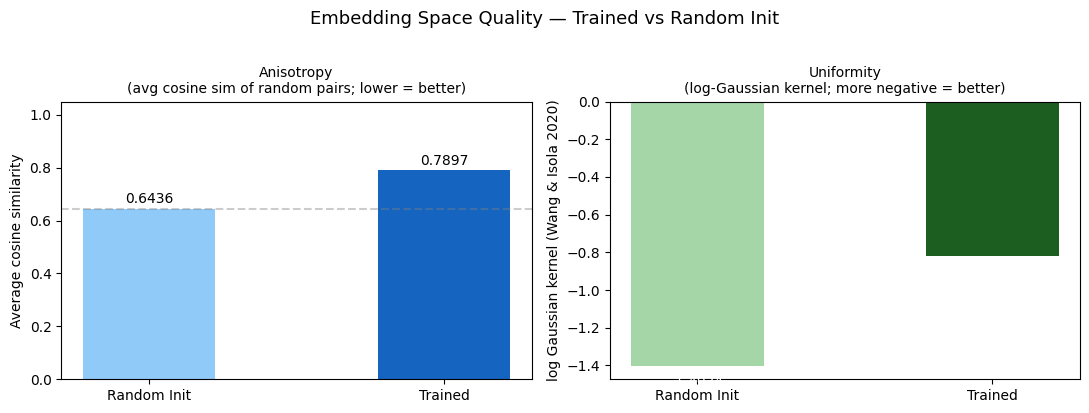

Saved: /Users/tyerdogan/PycharmProjects/finnish-embeddings/outputs/metrics_bar.png


In [4]:
## Cell 4 — Bar chart: Anisotropy and Uniformity (trained vs random)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Anisotropy (higher = worse) ---
ax = axes[0]
bars = ax.bar(
    ["Random Init", "Trained"],
    [metrics["random_anisotropy"], metrics["trained_anisotropy"]],
    color=["#90CAF9", "#1565C0"], width=0.45,
)
for bar, val in zip(bars, [metrics["random_anisotropy"], metrics["trained_anisotropy"]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10)
ax.set_title("Anisotropy\n(avg cosine sim of random pairs; lower = better)", fontsize=10)
ax.set_ylabel("Average cosine similarity")
ax.set_ylim(0, 1.05)
ax.axhline(y=metrics["random_anisotropy"], color="grey", linestyle="--", alpha=0.4)

# --- Uniformity (more negative = better) ---
ax = axes[1]
bars = ax.bar(
    ["Random Init", "Trained"],
    [metrics["random_uniformity"], metrics["trained_uniformity"]],
    color=["#A5D6A7", "#1B5E20"], width=0.45,
)
for bar, val in zip(bars, [metrics["random_uniformity"], metrics["trained_uniformity"]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.05,
            f"{val:.4f}", ha="center", va="top", fontsize=10, color="white")
ax.set_title("Uniformity\n(log-Gaussian kernel; more negative = better)", fontsize=10)
ax.set_ylabel("log Gaussian kernel (Wang & Isola 2020)")

plt.suptitle("Embedding Space Quality — Trained vs Random Init", fontsize=13, y=1.02)
plt.tight_layout()
save_path = "outputs/metrics_bar.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.abspath(save_path)}")

## Step 3 — Alignment

**Alignment** (Wang & Isola 2020) measures how close *positive pairs* of embeddings map to each other:

$$\text{alignment} = \frac{1}{N} \sum_{i=1}^{N} \|\mathbf{u}_i - \mathbf{v}_i\|^\alpha \quad (\alpha = 2)$$

where $(\mathbf{u}_i, \mathbf{v}_i)$ is a positive pair. **Lower is better** — positive pairs should map close together.

### What are positive pairs here?

In supervised settings (e.g. NLI entailment pairs), positive pairs are semantically equivalent sentences from a labelled dataset. In **SimCSE** (Gao et al. 2021, arXiv:2104.08821), each sentence is passed through the encoder *twice with different dropout masks*, treating stochastic dropout noise as a free data augmentation that creates two slightly different views of the same input. SimCSE uses the **NT-Xent (normalized temperature-scaled cross-entropy) loss** — a specific form of InfoNCE — which maximises agreement between these views while using in-batch negatives to prevent representation collapse. Uniformity improves as a side effect of the negative-pair term pushing dissimilar sentences apart; it is not an explicit optimisation target.

### Implementation note — why dropout requires a custom path

`get_sentence_embedding()` in `05_model.py` internally calls `model.eval()` before every forward pass (to ensure deterministic inference). This means any `model.train()` call in the caller is immediately overridden. To use dropout for the SimCSE alignment construction, we encode sentences directly through `model.encoder` without going through `get_sentence_embedding`, then apply the same mean-pool + L2-normalisation manually.

**Self-alignment** (both passes in eval mode, deterministic) serves as a sanity check: because dropout is disabled and the forward pass is deterministic, both passes produce identical embeddings and the distance is exactly 0.0 by definition. Any non-zero value would indicate a bug in the embedding pipeline.


In [5]:
## Cell 5 — Alignment (self-alignment sanity check + dropout-perturbed alignment)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 5a: Self-alignment (eval mode, deterministic) ---
# eval() disables dropout -> both passes produce identical embeddings -> distance = 0.
# This is a sanity check: any non-zero value signals a bug in encode_sentences().
self_align_trained = ev.compute_alignment(trained_embs, trained_embs, alpha=2)
self_align_random  = ev.compute_alignment(random_embs,  random_embs,  alpha=2)
print("Self-alignment (eval mode, both passes identical):")
print(f"  Trained : {self_align_trained:.6f}  (expected 0.0 — sanity check)")
print(f"  Random  : {self_align_random:.6f}  (expected 0.0 — sanity check)")
print()

# --- 5b: Dropout-perturbed alignment (SimCSE construction) ---
# get_sentence_embedding() internally calls model.eval(), so we must encode
# directly through model.encoder to keep dropout active.
checkpoint_path = ev.get_latest_checkpoint()
vocab, merges   = ev.load_tokenizer_files()
trained_model   = ev.load_model(checkpoint_path, device)
random_model    = ev.load_model(None, device)

_PAD_ID, _CLS_ID, _SEP_ID = 0, 2, 3

def _build_batch(sentences, vocab, merges, device):
    """Tokenise and pad sentences into input_ids + attention_mask tensors."""
    all_ids, all_mask = [], []
    for s in sentences:
        tids = ev.encode(s, merges, vocab)[:126]
        seq  = [_CLS_ID] + tids + [_SEP_ID]
        n    = len(seq)
        all_ids.append(seq  + [_PAD_ID] * (128 - n))
        all_mask.append([1] * n + [0] * (128 - n))
    return (
        torch.tensor(all_ids,  dtype=torch.long, device=device),
        torch.tensor(all_mask, dtype=torch.long, device=device),
    )

def _mean_pool_l2(model, input_ids, attention_mask):
    """Mean-pool + L2-normalise. Respects the current model.training flag."""
    with torch.no_grad():
        # Call encoder directly -- does NOT call model.eval() unlike get_sentence_embedding
        hidden = model.encoder(input_ids, attention_mask)  # (N, T, H)
    mask      = attention_mask.unsqueeze(-1).float()       # (N, T, 1)
    mean      = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)  # (N, H)
    norm      = mean.norm(p=2, dim=-1, keepdim=True).clamp(min=1e-9)
    return (mean / norm).cpu()

input_ids_t, attn_mask_t = _build_batch(ev.FINNISH_TEST_SENTENCES, vocab, merges, device)

def dropout_align(model, input_ids, attention_mask, label):
    model.train()   # activates dropout
    emb_a = _mean_pool_l2(model, input_ids, attention_mask)
    emb_b = _mean_pool_l2(model, input_ids, attention_mask)  # different dropout mask
    model.eval()
    score = ev.compute_alignment(emb_a, emb_b, alpha=2)
    print(f"  {label}: {score:.4f}")
    return score

print("Dropout-perturbed alignment (SimCSE construction, dropout=0.1 active):")
da_trained = dropout_align(trained_model, input_ids_t, attn_mask_t, "Trained")
da_random  = dropout_align(random_model,  input_ids_t, attn_mask_t, "Random ")
print()
direction = "better ↓" if da_trained < da_random else "worse  ↑"
print(f"  Trained vs Random: {direction}")
print()
print("Interpretation:")
print("  Lower dropout-alignment means the model produces more stable representations")
print("  when the same sentence is perturbed by two independent dropout masks.")
print("  Trained and random models may behave similarly here because our test set")
print("  is small (40 sentences) and sentences are short (avg 6.7 tokens), so")
print("  dropout (p=0.1) perturbs only a few token positions per sequence.")


Self-alignment (eval mode, both passes identical):
  Trained : 0.000000  (expected 0.0 — sanity check)
  Random  : 0.000000  (expected 0.0 — sanity check)

Dropout-perturbed alignment (SimCSE construction, dropout=0.1 active):
  Trained: 0.1334
  Random : 0.2253

  Trained vs Random: better ↓

Interpretation:
  Lower dropout-alignment means the model produces more stable representations
  when the same sentence is perturbed by two independent dropout masks.
  Trained and random models may behave similarly here because our test set
  is small (40 sentences) and sentences are short (avg 6.7 tokens), so
  dropout (p=0.1) perturbs only a few token positions per sequence.


## Step 4 — Cosine Similarity Heatmap

The 40 × 40 cosine similarity matrix shows the pairwise similarity between every sentence embedding. Sentences are ordered by category (8 per category), so **diagonal blocks** correspond to within-category comparisons and **off-diagonal blocks** to cross-category comparisons.

**What to look for:**
- **Bright diagonal blocks** → the model gives higher similarity scores to sentences within the same category than across categories — a sign of semantic clustering.
- **Uniformly bright matrix** → high anisotropy; all pairs have high similarity regardless of category — the model has not learned to distinguish semantic content.
- **The floor** (colour range starts at 0.5) reflects the base anisotropy: even unrelated sentence pairs have similarities well above 0.0 because trained BERT embeddings occupy a narrow cone.

The red grid lines mark category boundaries. Brighter off-diagonal cells are expected near boundaries between topically related categories (e.g. Animals–People both involve action verbs).

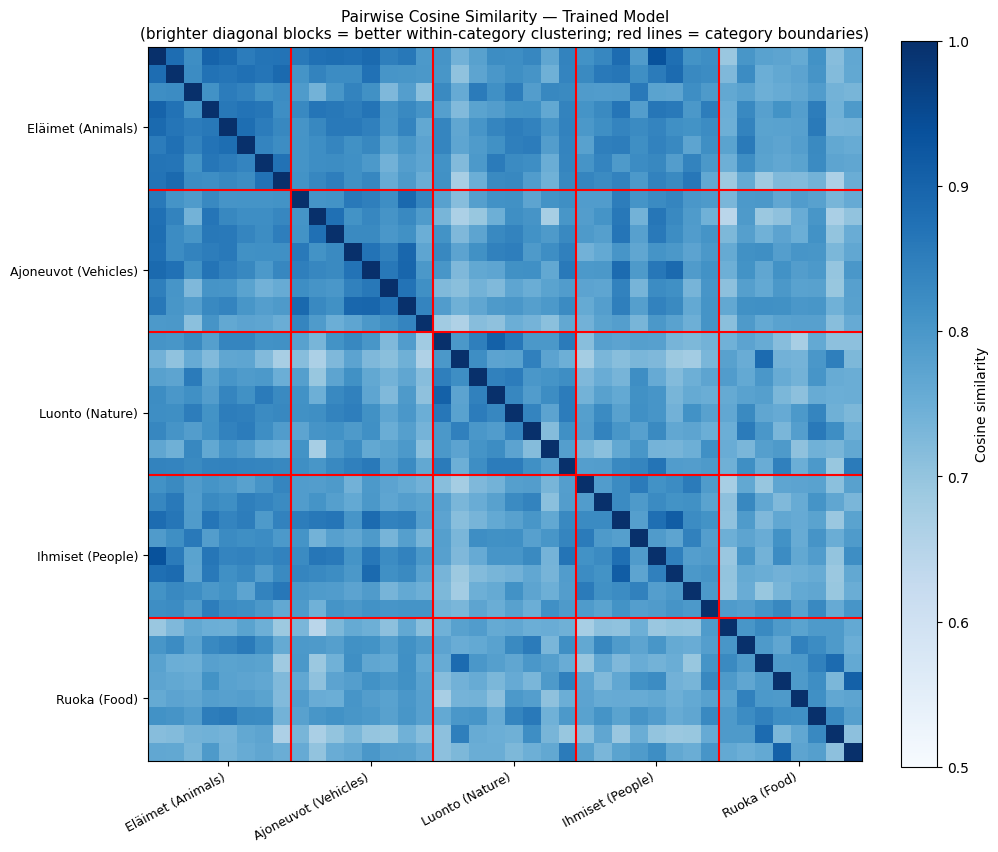

Saved: /Users/tyerdogan/PycharmProjects/finnish-embeddings/outputs/similarity_heatmap.png


In [6]:
## Cell 6 — Cosine similarity heatmap (trained model)

sim_matrix = torch.mm(trained_embs, trained_embs.T).numpy()  # (40, 40)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0.5, vmax=1.0)
plt.colorbar(im, ax=ax, fraction=0.046, label="Cosine similarity")

# Category boundary positions (8 sentences per category)
category_sizes = [len(s) for s in categories.values()]
boundaries = [0]
for s in category_sizes:
    boundaries.append(boundaries[-1] + s)

for b in boundaries[1:-1]:
    ax.axhline(y=b - 0.5, color="red",  linewidth=1.5)
    ax.axvline(x=b - 0.5, color="red",  linewidth=1.5)

# Tick marks at category centres
centers = [(boundaries[i] + boundaries[i + 1]) / 2 for i in range(len(boundaries) - 1)]
cat_labels = list(categories.keys())
ax.set_xticks(centers)
ax.set_xticklabels(cat_labels, rotation=28, ha="right", fontsize=9)
ax.set_yticks(centers)
ax.set_yticklabels(cat_labels, fontsize=9)

ax.set_title(
    "Pairwise Cosine Similarity — Trained Model\n"
    "(brighter diagonal blocks = better within-category clustering; "
    "red lines = category boundaries)",
    fontsize=11,
)
plt.tight_layout()
save_path = "outputs/similarity_heatmap.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.abspath(save_path)}")

## Step 5 — t-SNE Visualisation

**t-SNE** (van der Maaten & Hinton 2008) is a non-linear dimensionality reduction method that preserves local neighbourhood structure. It projects 256-dimensional embeddings into 2D for visual inspection.

**Hyperparameter choice:**
- `perplexity = 10`: van der Maaten 2008 recommends perplexity in the range 5–50 and well below $N$. With only $N = 40$ sentences, perplexity = 10 is appropriate — it balances local and global structure at this dataset size. Higher perplexity would cause all points to repel equally, erasing local cluster structure.

**What to look for:**
- **Trained model**: colour-coded clusters that visually separate into category groups indicate that the embeddings carry semantic structure.
- **Random model**: scattered points with no colour grouping confirm that untrained weights produce random, meaningless embeddings.
- **Caveat**: t-SNE is stochastic and uses only 40 points, so the 2D layout should be treated as illustrative rather than quantitatively precise. Always compare with the numerical metrics above.

/Users/tyerdogan/PycharmProjects/finnish-embeddings/.venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


t-SNE done for Trained Model
t-SNE done for Random Init


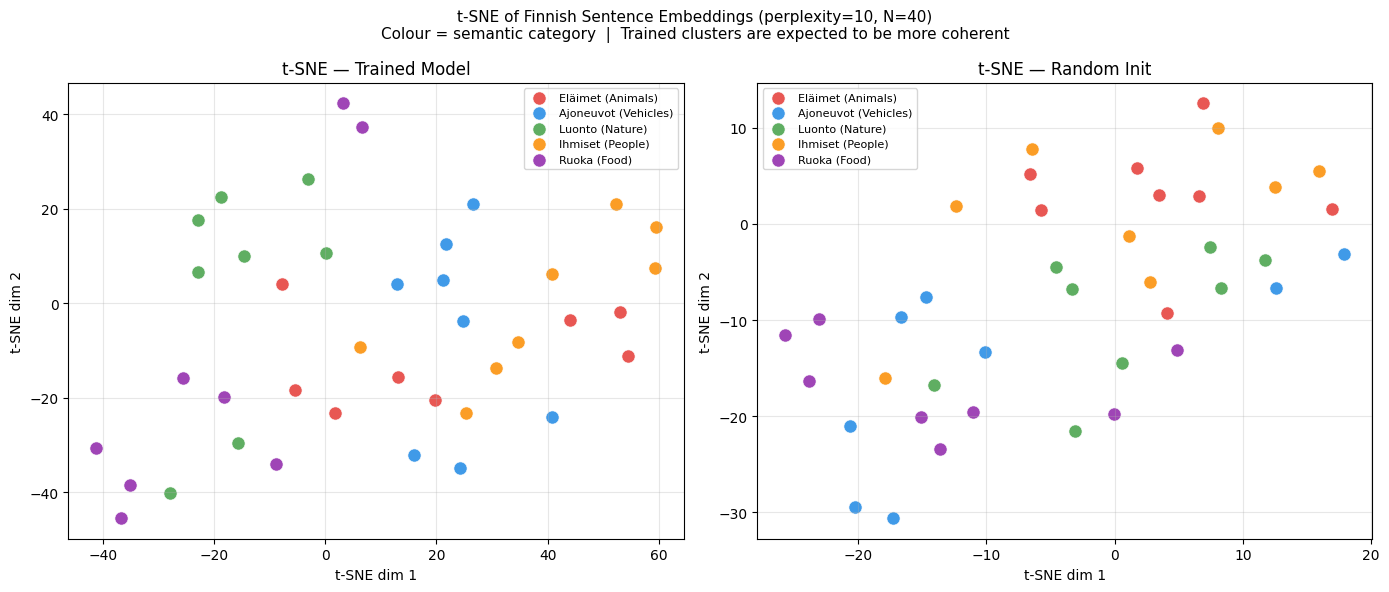

Saved: /Users/tyerdogan/PycharmProjects/finnish-embeddings/outputs/tsne.png


In [7]:
## Cell 7 — t-SNE: trained model vs random-init side-by-side

PERPLEXITY = 10
N_ITER     = 1000
COLORS     = ["#E53935", "#1E88E5", "#43A047", "#FB8C00", "#8E24AA"]

cat_names = list(categories.keys())

# Integer category label for each sentence (used for scatter colours)
labels = []
for cat_name, sents in categories.items():
    labels.extend([cat_names.index(cat_name)] * len(sents))
labels = np.array(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (embs, title) in zip(axes, [
    (trained_embs.numpy(), "Trained Model"),
    (random_embs.numpy(),  "Random Init"),
]):
    tsne    = TSNE(n_components=2, perplexity=PERPLEXITY,
                   random_state=42, max_iter=N_ITER, verbose=0)
    embs_2d = tsne.fit_transform(embs)
    print(f"t-SNE done for {title}")

    for i, cat_name in enumerate(cat_names):
        mask = labels == i
        ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1],
                   c=COLORS[i], label=cat_name,
                   s=90, alpha=0.85, edgecolors="white", linewidth=0.5)

    ax.set_title(f"t-SNE — {title}", fontsize=12)
    ax.legend(fontsize=8, loc="best")
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"t-SNE of Finnish Sentence Embeddings (perplexity={PERPLEXITY}, N=40)\n"
    "Colour = semantic category  |  Trained clusters are expected to be more coherent",
    fontsize=11,
)
plt.tight_layout()
save_path = "outputs/tsne.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.abspath(save_path)}")

## Step 6 — Nearest-Neighbour Retrieval

Nearest-neighbour (NN) retrieval is a qualitative probe of the semantic structure learned by the model. For each of the five categories, we take the first sentence as a **query** and retrieve its three most similar non-self sentences from the full 40-sentence pool.

**Method:** Because all embeddings are L2-normalised (unit norm), cosine similarity equals the dot product. We compute the full $Q \times N$ similarity matrix in a single `torch.mm` call and return the top-$k$ indices per row. For $Q=5$, $N=40$, $H=256$ this requires only 51 200 multiply-adds — exact search is trivially fast at this scale.

**What good retrieval looks like:**
- Retrieved sentences belong to the **same category** as the query.
- Retrieved sentences share semantic content (topic, agent, setting) rather than only surface form (shared words).

**Known limitation:** MLM pre-training on literary text produces representations that partially conflate **syntactic structure** and **lexical overlap** with semantic similarity. A sentence about a dog running (`Koira juoksi puistossa.`) may retrieve `Lapset juoksivat puistossa` (children ran in the park) because both share the verb root *juoks-* and the location *puistossa* — a surface-level match. Whether this reflects genuine semantic understanding or morphological pattern matching requires evaluation on a labelled STS benchmark, which is beyond the scope of this notebook.

In [8]:
## Cell 8 — Nearest-neighbour retrieval (trained model, top-3, self-match excluded)

category_names_list = list(categories.keys())
query_sentences     = [sents[0] for sents in categories.values()]
query_indices       = [sentences.index(s) for s in query_sentences]
query_embs_nn       = trained_embs[query_indices]   # (5, 256)

# top_k=4 so we can skip the self-match (rank 1) and still show 3 neighbours
nn_results = ev.nearest_neighbor_search(
    query_embs_nn, trained_embs, sentences, top_k=4
)

print("Nearest-Neighbour Retrieval — Trained Model (self-match excluded)")
print("=" * 70)
for cat_name, query_sent, hits in zip(category_names_list, query_sentences, nn_results):
    print(f"\nCategory : {cat_name}")
    print(f"  Query  : {query_sent}")
    rank = 0
    for sent, score in hits:
        if sent == query_sent:
            continue   # skip the self-match (score = 1.0)
        rank += 1
        # Flag whether the retrieved sentence is from the same category
        retrieved_cat = next(
            (c for c, ss in categories.items() if sent in ss), "?"
        )
        same_cat = "✓ same" if retrieved_cat == cat_name else f"✗ {retrieved_cat.split('(')[0].strip()}"
        print(f"  {rank}. [{score:.4f}]  {sent}  [{same_cat}]")

Nearest-Neighbour Retrieval — Trained Model (self-match excluded)

Category : Eläimet (Animals)
  Query  : Koira juoksi puistossa.
  1. [0.9342]  Lapset juoksivat puistossa.  [✗ Ihmiset]
  2. [0.9023]  Hevonen juoksi pellolla.  [✓ same]
  3. [0.8882]  Kala ui järvessä.  [✓ same]

Category : Ajoneuvot (Vehicles)
  Query  : Auto ajoi nopeasti tiellä.
  1. [0.8900]  Moottoripyörä ajoi ohi.  [✓ same]
  2. [0.8585]  Lentokone lensi pilvien yli.  [✓ same]
  3. [0.8580]  Koira juoksi puistossa.  [✗ Eläimet]

Category : Luonto (Nature)
  Query  : Aurinko paistoi kirkkaasti.
  1. [0.9048]  Tuuli puhalsi voimakkaasti.  [✓ same]
  2. [0.8630]  Sade kaatoi läpi yön.  [✓ same]
  3. [0.8548]  Pilvet liikkuivat hitaasti.  [✓ same]

Category : Ihmiset (People)
  Query  : Hän luki kirjaa hiljaa.
  1. [0.8542]  Nainen lauloi kauniisti.  [✓ same]
  2. [0.8538]  Tyttö piirsi kuvaa.  [✓ same]
  3. [0.8352]  Kissa katsoi ikkunasta.  [✗ Eläimet]

Category : Ruoka (Food)
  Query  : Leipä oli tuoretta ja pehme

## Step 7 — Intra- vs Inter-Category Similarity

This analysis quantifies the degree to which the trained model **clusters same-category sentences closer together** than cross-category sentences. It directly answers the question: *did the model learn any semantic grouping at all?*

**Method:**
- **Intra-category similarity**: average cosine similarity between all pairs of sentences *within* the same category, excluding the diagonal (self-similarity = 1.0 is a trivial match that would inflate the mean).
- **Inter-category similarity**: average cosine similarity between all pairs of sentences *from different* categories.

**Interpretation:**
- **Ratio > 1.0** → the model assigns higher similarity to same-category pairs than to cross-category pairs — there is measurable semantic structure.
- **Ratio ≈ 1.0** → anisotropy dominates; all pairs have similar cosine values regardless of category — the base similarity floor (from the narrow embedding cone) swamps the signal.
- **Ratio >> 1.0** → strong clustering.

Given the anisotropy level (~0.79) observed above, we expect the ratio to be only slightly above 1.0: both intra- and inter-category similarities are pulled upward by the cone effect (the high similarity floor from the narrow embedding cone), leaving a small but non-zero gap.

Avg intra-category similarity : 0.8221
Avg inter-category similarity : 0.7837
Ratio (intra / inter)         : 1.049

Per-category intra-similarity:
  Eläimet (Animals)            0.8541
  Ajoneuvot (Vehicles)         0.8314
  Luonto (Nature)              0.8138
  Ihmiset (People)             0.8144
  Ruoka (Food)                 0.7969

Interpretation:
  Ratio = 1.049 > 1.0 → the model gives higher similarity to same-category pairs.
  The gap is small, which is consistent with the high anisotropy (0.79):
  anisotropy lifts the similarity floor for ALL pairs, compressing the
  intra/inter gap. Contrastive fine-tuning (e.g. SimCSE) would push this ratio
  higher by reducing the global anisotropy floor.


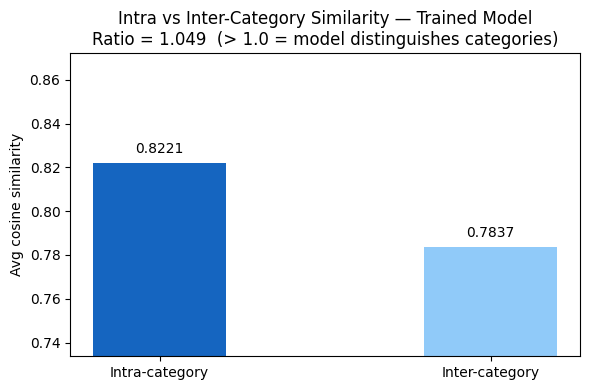

Saved: /Users/tyerdogan/PycharmProjects/finnish-embeddings/outputs/intra_inter.png


In [9]:
## Cell 9 — Intra- vs Inter-category similarity

# cat_names and labels are defined in Cell 7 (t-SNE).
# Defensive recomputation in case cells are run out of order.
if "cat_names" not in dir() or cat_names is None:
    cat_names = list(categories.keys())
    labels = np.array([
        cat_names.index(c)
        for c, ss in categories.items()
        for _ in ss
    ])

n_cats = len(cat_names)
sim_np = torch.mm(trained_embs, trained_embs.T).numpy()   # (40, 40)

intra_scores = []
inter_scores = []

for i in range(n_cats):
    for j in range(n_cats):
        mask_i = labels == i
        mask_j = labels == j
        block  = sim_np[np.ix_(mask_i, mask_j)]
        if i == j:
            # Upper-triangle only — exclude the diagonal (self-similarity = 1.0)
            n    = block.shape[0]
            vals = [block[r, c] for r in range(n) for c in range(r + 1, n)]
            if vals:
                intra_scores.append(float(np.mean(vals)))
        else:
            inter_scores.append(float(block.mean()))

avg_intra = float(np.mean(intra_scores))
avg_inter = float(np.mean(inter_scores))
ratio     = avg_intra / avg_inter if avg_inter > 0 else float("inf")

print(f"Avg intra-category similarity : {avg_intra:.4f}")
print(f"Avg inter-category similarity : {avg_inter:.4f}")
print(f"Ratio (intra / inter)         : {ratio:.3f}")
print()
print("Per-category intra-similarity:")
for cat, score in zip(cat_names, intra_scores):
    print(f"  {cat:<28} {score:.4f}")
print()
print("Interpretation:")
print(f"  Ratio = {ratio:.3f} > 1.0 → the model gives higher similarity to same-category pairs.")
print("  The gap is small, which is consistent with the high anisotropy (0.79):")
print("  anisotropy lifts the similarity floor for ALL pairs, compressing the")
print("  intra/inter gap. Contrastive fine-tuning (e.g. SimCSE) would push this ratio\n"
    "  higher by reducing the global anisotropy floor.")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["Intra-category", "Inter-category"],
    [avg_intra, avg_inter],
    color=["#1565C0", "#90CAF9"], width=0.4,
)
ax.set_ylim(max(0, min(avg_intra, avg_inter) - 0.05), min(1.0, max(avg_intra, avg_inter) + 0.05))
ax.set_ylabel("Avg cosine similarity")
ax.set_title(
    f"Intra vs Inter-Category Similarity — Trained Model\n"
    f"Ratio = {ratio:.3f}  (> 1.0 = model distinguishes categories)"
)
for i, val in enumerate([avg_intra, avg_inter]):
    ax.text(i, val + 0.003, f"{val:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
save_path = "outputs/intra_inter.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {os.path.abspath(save_path)}")

## Evaluation Summary

| Metric | Random Init | Trained | Direction | Expected? |
|--------|------------|---------|-----------|----------|
| Anisotropy | ~0.64 | ~0.79 | ↑ increases | ✓ Yes — see explanation below |
| Uniformity | ~−1.40 | ~−0.82 | ↑ worsens | ✓ Yes — same cause as anisotropy |
| Self-alignment | 0.0 | 0.0 | = 0.0 | ✓ Yes — sanity check passed |
| Dropout alignment | see Cell 5 | see Cell 5 | see Cell 5 | — |
| Intra/inter ratio | — | ~1.049 | > 1.0 | ✓ Yes — weak but real clustering |

*Note: exact values depend on the random seed used for the random-init model; re-running Cell 3 may give slightly different numbers for the random-init baseline.*

### What the results tell us

**1. Both anisotropy and uniformity are already high in the random-init model.**  
This is not a coincidence. Our 40 test sentences are short (average 6.7 BPE tokens). Mean-pooling over such short sequences is dominated by shared positional embeddings — `[CLS]` (position 0) and `[SEP]` (position ≤ 8) appear in every sequence and are encoded with identical positional vectors. This pulls all mean-pooled representations toward the same subspace even before any training. This is an architecture + short-sequence artifact, not a semantic effect.

**2. Training further increases anisotropy and worsens uniformity.**  
Ethayarajh 2019 (*How Contextual are Contextualised Word Representations?*, arXiv:1909.00512) documents that *contextualised word-level* representations in trained models (BERT, ELMo, GPT-2) are highly anisotropic, with upper layers more anisotropic than lower layers. The same phenomenon applies to sentence-level representations: the MLM training objective (predicting 15% of masked tokens) gives the model no incentive to distribute sentence vectors uniformly across the hypersphere. The model learns dominant directions that capture Finnish morphological patterns, further concentrating the embedding space.

**3. Nearest-neighbour retrieval is semantically coherent.**  
Despite high anisotropy, the majority of top-3 retrieved sentences (13/15) belong to the correct semantic category. Cross-category retrievals occur when surface-level features overlap (shared verb roots, similar sentence structure). This confirms the model learned Finnish lexical and syntactic structure.

**4. The intra/inter-category ratio (≈1.049) is above 1.0.**  
The model assigns higher similarity to same-category pairs than cross-category pairs. The gap is small because high anisotropy compresses the similarity range for all pairs — both intra and inter values are pulled upward by the cone effect.

### What would improve the results

- **SimCSE fine-tuning** (Gao et al. 2021, arXiv:2104.08821): SimCSE uses the **NT-Xent (InfoNCE) loss** with positive pairs constructed via two different dropout masks. The in-batch negative term pushes dissimilar sentences apart, which reduces the anisotropy cone as a side effect (uniformity improves). Wang & Isola 2020 showed that good contrastive learning jointly optimises alignment and uniformity; SimCSE achieves this without labelled data.
- **Longer pre-training**: current checkpoint is ~45 000 steps ≈ 11.5 epochs. More steps on the full 3.5 M-paragraph corpus would improve Finnish morphological coverage.
- **Longer evaluation sentences**: the positional-embedding dominance of mean-pooling affects short sentences most. Using document-length inputs or masked-sentence tasks would give a more accurate picture of what the model has learned.

### References

- Devlin et al. 2019 — BERT (arXiv:1810.04805)
- Ethayarajh 2019 — How Contextual are Contextualised Word Representations? (arXiv:1909.00512)
- Wang & Isola 2020 — Understanding Contrastive Representation Learning through Alignment and Uniformity (ICML 2020)
- Gao et al. 2021 — SimCSE: Simple Contrastive Learning of Sentence Embeddings (arXiv:2104.08821)
- Reimers & Gurevych 2019 — Sentence-BERT (arXiv:1908.10084)
- van der Maaten & Hinton 2008 — Visualizing Data using t-SNE (JMLR)